In [74]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

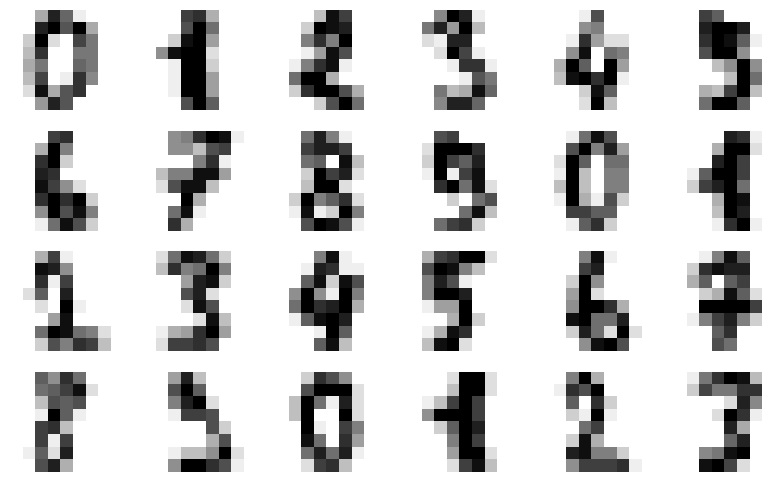

In [2]:
digits = load_digits()

fig, axes = plt.subplots(4, 6, figsize=(10, 6))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(digits.images[i], cmap=plt.cm.gray_r)
    ax.axis('off')
plt.show()

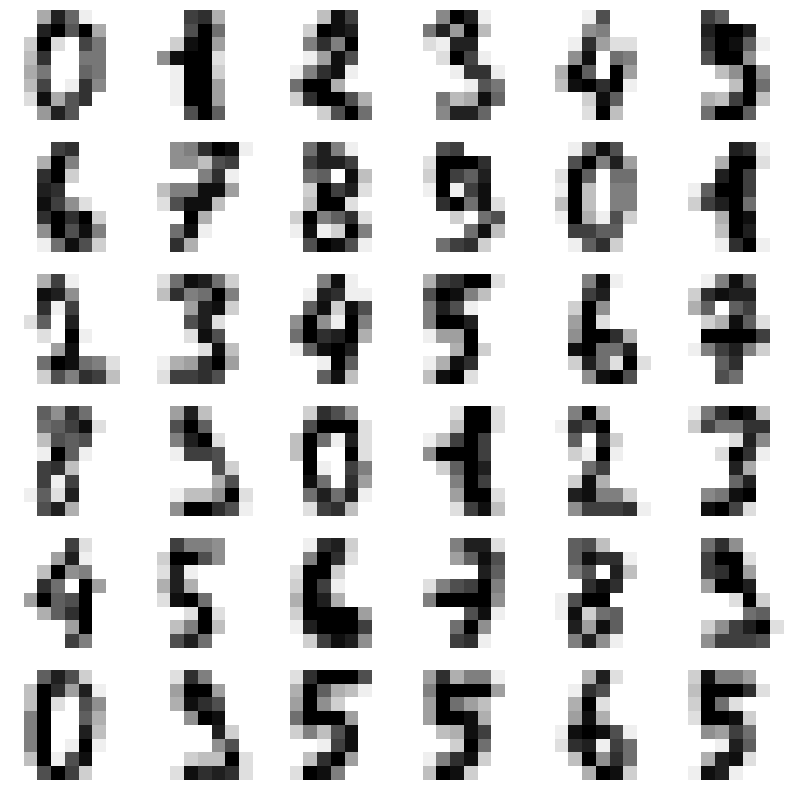

In [3]:
fig, axes = plt.subplots(6, 6, figsize=(10, 10))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(digits.images[i], cmap=plt.cm.gray_r)
    ax.axis('off')
plt.show()

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    digits.data, 
    digits.target, 
    test_size=0.20,
    random_state=11)

display(X_train.shape)
display(X_test.shape)

(1437, 64)

(360, 64)

In [11]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [13]:
predicted = knn.predict(X_test)
expected = y_test

print(predicted[:36])
print(expected[:36])

for i in range(expected.size):
    if predicted[i] != expected[i]:
        print(f"{i}: {predicted[i]} - {expected[i]}")

[0 4 9 9 3 1 4 1 5 0 4 9 4 1 5 3 3 8 5 6 9 6 0 6 9 3 2 1 8 1 7 0 4 4 1 5]
[0 4 9 9 3 1 4 1 5 0 4 9 4 1 5 3 3 8 3 6 9 6 0 6 9 3 2 1 8 1 7 0 4 4 1 5]
18: 5 - 3
51: 8 - 9
144: 4 - 9
152: 7 - 3
201: 7 - 4


In [14]:
score = knn.score(X_test, y_test)
print(score)

0.9861111111111112


In [64]:
def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    
    cm_df = pd.DataFrame(cm, index=range(10), columns=range(10))

    plt.figure(figsize=(10, 7))
    sns.heatmap(cm_df, annot=True, cmap='nipy_spectral_r')
    plt.show()

[[38  0  0  0  0  0  0  0  0  0]
 [ 0 37  0  0  0  0  0  0  0  0]
 [ 0  0 39  0  0  0  0  0  0  0]
 [ 0  0  0 39  0  1  0  1  0  0]
 [ 0  0  0  0 40  0  0  1  0  0]
 [ 0  0  0  0  0 27  0  0  0  0]
 [ 0  0  0  0  0  0 30  0  0  0]
 [ 0  0  0  0  0  0  0 36  0  0]
 [ 0  0  0  0  0  0  0  0 34  0]
 [ 0  0  0  0  1  0  0  0  1 35]]


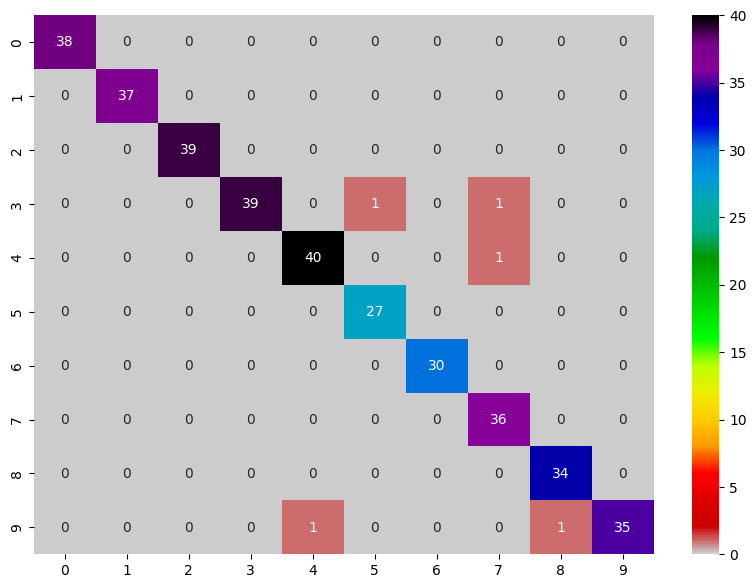

In [20]:
plot_confusion_matrix(expected, predicted)

In [7]:
print(classification_report(expected, predicted))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        38
           1       1.00      1.00      1.00        37
           2       1.00      1.00      1.00        39
           3       1.00      0.95      0.97        41
           4       0.98      0.98      0.98        41
           5       0.96      1.00      0.98        27
           6       1.00      1.00      1.00        30
           7       0.95      1.00      0.97        36
           8       0.97      1.00      0.99        34
           9       1.00      0.95      0.97        37

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360



In [23]:
models = {
    'KNeighborsClassifier': KNeighborsClassifier(),
    'SVC': SVC(),
    'GaussianNB': GaussianNB()
}

fitted_models = {}

for name, model in models.items():
    fitted_models[name] = model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    print(f"{name}: {score}")

KNeighborsClassifier: 0.9861111111111112
SVC: 0.9861111111111112
GaussianNB: 0.8555555555555555


We got identical scores for KNN and SVC, thus we gotta determine the better one.

In [57]:
knn_predicted = fitted_models['KNeighborsClassifier'].predict(X_test)
svc_predicted = fitted_models['SVC'].predict(X_test)

knn_df = pd.DataFrame(classification_report(expected, knn_predicted, output_dict=True)).T.round(2)
svc_df = pd.DataFrame(classification_report(expected, svc_predicted, output_dict=True)).T.round(2)

diff_df = svc_df - knn_df

def highlight_differences(data, diff):
    styles = pd.DataFrame('', index=data.index, columns=data.columns)
    styles[diff != 0] = 'background-color: gray; color: black'
    return styles

knn_style = knn_df.style.format("{:.2f}").apply(highlight_differences, diff=diff_df, axis=None)
svc_style = svc_df.style.format("{:.2f}").apply(highlight_differences, diff=diff_df, axis=None)

display(knn_style)
display(svc_style)

,precision,recall,f1-score,support
0,1.00,1.00,1.00,38.00
1,1.00,1.00,1.00,37.00
2,1.00,1.00,1.00,39.00
3,1.00,0.95,0.98,41.00
4,0.98,0.98,0.98,41.00
5,0.96,1.00,0.98,27.00
6,1.00,1.00,1.00,30.00
7,0.95,1.00,0.97,36.00
8,0.97,1.00,0.99,34.00
9,1.00,0.95,0.97,37.00


,precision,recall,f1-score,support
0,1.00,1.00,1.00,38.00
1,1.00,1.00,1.00,37.00
2,1.00,1.00,1.00,39.00
3,1.00,0.93,0.96,41.00
4,1.00,1.00,1.00,41.00
5,0.96,1.00,0.98,27.00
6,1.00,1.00,1.00,30.00
7,0.95,0.97,0.96,36.00
8,0.97,1.00,0.99,34.00
9,0.97,0.97,0.97,37.00


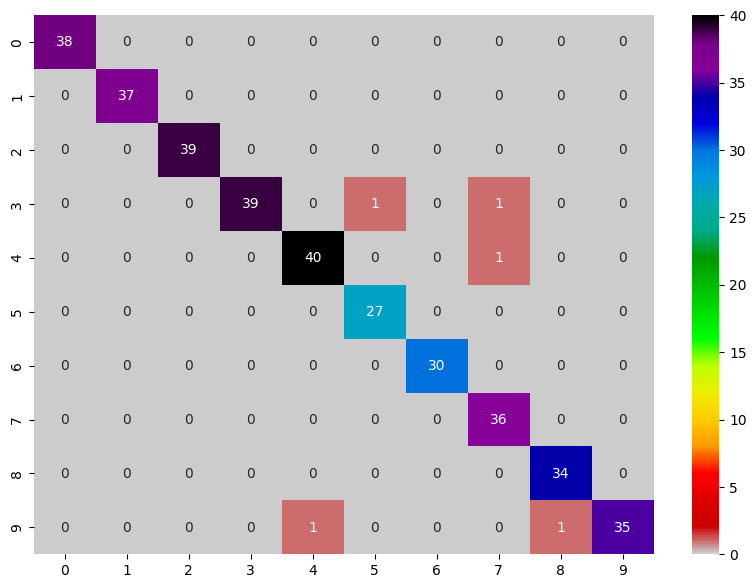

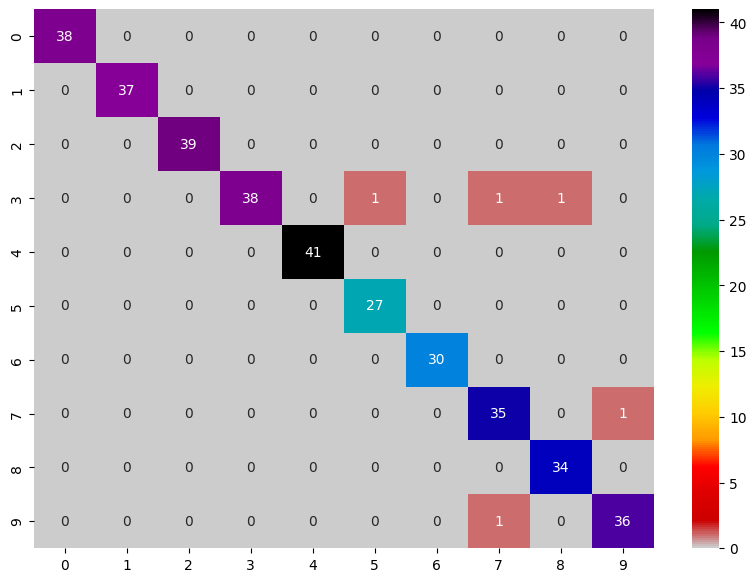

In [65]:
plot_confusion_matrix(expected, knn_predicted)
plot_confusion_matrix(expected, svc_predicted)

In [ ]:


knn_params = {
    'n_neighbors': range(1, 21, 2),
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

grid_knn = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5)
grid_knn.fit(X_train, y_train)

print(f"Best Parameters: {grid_knn.best_params_}")
print(f"Best Test Score: {grid_knn.best_score_}")

Best Parameters: {'n_neighbors': 3, 'p': 2, 'weights': 'distance'}
Best Test Score: 0.9847004452187379


In [70]:
svc_params = {
    'C': [0.1, 1, 10],
    'gamma': [0.0001, 0.001, 0.01, 0.1],
    'kernel': ['rbf', 'poly', 'linear']
}
grid = GridSearchCV(SVC(), svc_params, cv=5)
grid.fit(X_train, y_train)

print(f"Best Parameters: {grid.best_params_}")
print(f"Best Test Score: {grid.best_score_}")

Best Parameters: {'C': 1, 'gamma': 0.001, 'kernel': 'rbf'}
Best Test Score: 0.9902584204413472


In [80]:
knn_best = KNeighborsClassifier(n_neighbors=3, p=2, weights='distance')
svc_best = SVC(C=1, gamma=0.001, kernel='rbf')

In [ ]:
knn_cv_scores = cross_val_score(knn_best, digits.data, digits.target, cv=20)
svc_cv_scores = cross_val_score(svc_best, digits.data, digits.target, cv=20)

print(f"KNN Cross-Validation Scores: {knn_cv_scores}")
print(f"KNN Average Score: {knn_cv_scores.mean():.4f}\n")

print(f"SVC Cross-Validation Scores: {svc_cv_scores}")
print(f"SVC Average Score: {svc_cv_scores.mean():.4f}")

KNN Cross-Validation Scores: [0.93333333 0.98888889 0.98888889 1.         0.98888889 0.98888889
 0.97777778 0.98888889 1.         0.95555556 1.         0.98888889
 0.97777778 1.         0.98888889 0.98888889 1.         0.97752809
 0.95505618 0.98876404]
KNN Average Score: 0.9838

SVC Cross-Validation Scores: [0.95555556 0.98888889 1.         1.         0.98888889 0.97777778
 0.97777778 1.         1.         0.98888889 0.97777778 1.
 0.98888889 1.         1.         0.98888889 1.         0.94382022
 0.97752809 0.97752809]
SVC Average Score: 0.9866


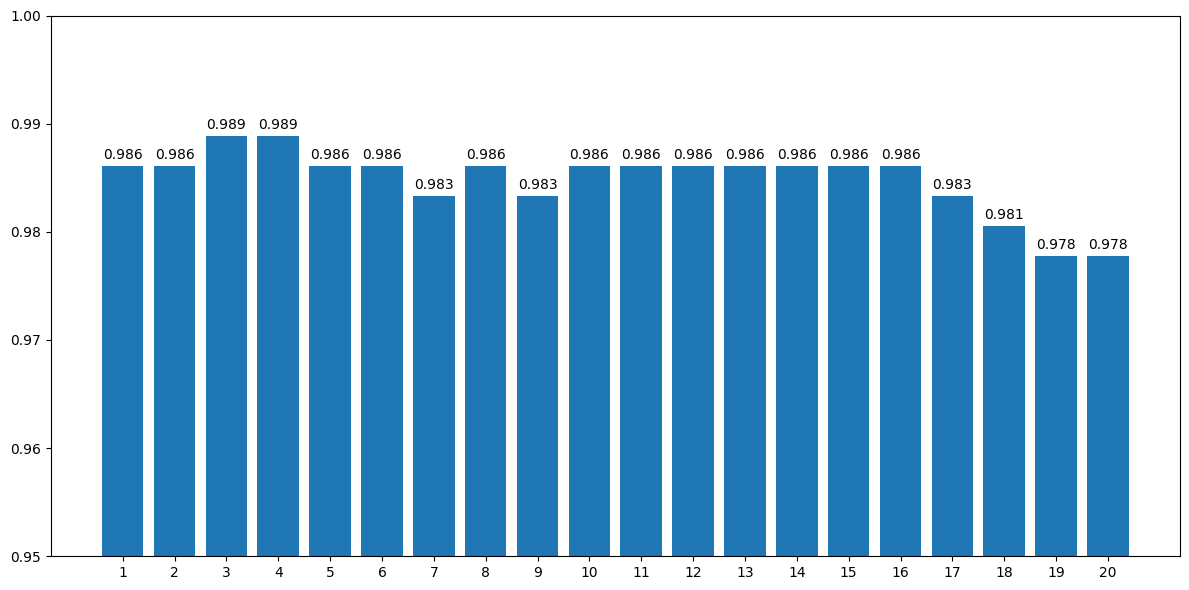

In [85]:
scores = []
for k in range(1, 21):
    knn_k = knn_best.set_params(n_neighbors=k)
    knn_k.fit(X_train, y_train)
    scores.append(knn_k.score(X_test, y_test))

plt.figure(figsize=(12, 6))
bars = plt.bar(range(1, 21), scores)
plt.xticks(range(1, 21))
plt.bar_label(bars, fmt='%.3f', padding=3)
plt.ylim(0.95, 1.0)
plt.tight_layout()
plt.show()